# Single-Energy EXFOR Fitting and Sampling Demo

This notebook demonstrates the EXFOR angular distribution fitting and sampling workflow
for a **single energy point**. It allows you to visualize and understand each step of
the fitting process used in `exfor_to_endf_sampling_v2.py`.

## Key Features
- Set target energy at the top and see the complete workflow
- Visualize EXFOR experimental data with uncertainties
- Compare nominal fit, MC samples, and original ENDF evaluation
- Understand how Legendre coefficients are fitted and sampled

## 1. Configuration Parameters

Modify these parameters to explore different energies and fitting settings.

In [50]:
# ============================================================================
# USER CONFIGURABLE PARAMETERS
# ============================================================================

# Target energy to analyze (MeV)
TARGET_ENERGY_MEV = 1.31

# Data source configuration
ENDF_FILE = "/soft_snc/lib/endf/jeff40/neutrons/26-Fe-56g.txt"
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET_ZAIDS = [26056, 26000]  # Fe-56 + natural iron
MT_NUMBER = 2  # Elastic scattering

# Supplementary JSON files (experiments not in database)
SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',  # Gkatis (2025)
]

# Experiment exclusion and uncertainty handling
# Use this to exclude specific experiments from the fit
EXCLUDE_EXPERIMENTS = ["20743002"]  # e.g., ["20743002"] to exclude Cierjacks (1978)

# Minimum relative uncertainty floor (set to 0.0 to disable)
# This prevents experiments with unrealistically small uncertainties from dominating
MIN_RELATIVE_UNCERTAINTY = 0.03  # e.g., 0.03 for 3% minimum uncertainty floor

# ACE file for cross section folding (energy-dependent normalization)
ACE_FILE_PATH = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_40.02c'
COVARIANCE_FILE = '/soft_snc/lib/cov/80/600/260560_80.06.xs.gendf'

# Target masses for LAB->CM conversion
M_PROJ_U = 1.008665  # Neutron mass (u)
M_TARG_U = 55.93494  # Fe-56 mass (u)

# Fitting parameters
MAX_LEGENDRE_DEGREE = 8
SELECT_DEGREE = "aicc"  # "aicc", "bic", or None (use max)
RIDGE_LAMBDA = 1e-6

# Experiment selection method: "energy_bin" or "kernel_weights"
EXPERIMENT_SELECTION_METHOD = "energy_bin"

# TOF energy resolution parameters (for kernel_weights method)
DELTA_T_NS = 5.0      # Time resolution (ns)
FLIGHT_PATH_M = 27.037  # Flight path (m)
N_SIGMA_CUTOFF = 3.0  # Kernel cutoff in sigma units

# Band discrepancy parameters
USE_BAND_DISCREPANCY = True
MIN_POINTS_PER_BAND = 3
MAX_TAU_FRACTION = 0.25

# Sampling parameters
N_SAMPLES = 25  # Number of MC samples to generate
BASE_SEED = 42

print(f"Target energy: {TARGET_ENERGY_MEV} MeV")
print(f"Method: {EXPERIMENT_SELECTION_METHOD}")
print(f"Max Legendre degree: {MAX_LEGENDRE_DEGREE}")
print(f"MC samples: {N_SAMPLES}")
print(f"Supplementary JSON files: {len(SUPPLEMENTARY_JSON_FILES)}")
print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS if EXCLUDE_EXPERIMENTS else 'None'}")
print(f"Min relative uncertainty floor: {MIN_RELATIVE_UNCERTAINTY*100:.1f}%" if MIN_RELATIVE_UNCERTAINTY > 0 else "Min relative uncertainty floor: Disabled")
print(f"ACE file: {ACE_FILE_PATH}")

Target energy: 1.31 MeV
Method: energy_bin
Max Legendre degree: 8
MC samples: 25
Supplementary JSON files: 1
Excluded experiments: ['20743002']
Min relative uncertainty floor: 3.0%
ACE file: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_40.02c


## 2. Imports and Setup

In [34]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval

# Add kika to path if needed
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

# Import kika modules
from kika.endf import read_endf
from kika.endf.classes.mf4.polynomial import MF4MTLegendre
from kika.endf.classes.mf4.mixed import MF4MTMixed
from kika.exfor import read_all_exfor
import kika.exfor as exfor

# Import scripts modules
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    compute_energy_bins_with_tof_resolution,
    filter_exfor_with_energy_bin,
    filter_exfor_with_kernel_weights,
    EnergyBinInfo,
)
from scripts.resample_AD import (
    sample_legendre_coefficients,
    endf_normalize_legendre_coeffs,
    compute_angular_band_discrepancy,
)

# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

print("Imports successful!")

Imports successful!


## 3. Load EXFOR Data

Load all available EXFOR angular distribution data for Fe-56 and natural iron.

In [35]:
print("Loading EXFOR data from database...")

# Load EXFOR data using the new API
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS,
    mt=MT_NUMBER,
    source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,  # Include supplementary experiments
    exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
)

# Convert to cache format
exfor_objects = list(exfor_dict.values())
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    exfor_objects, 
    exclude_experiments=EXCLUDE_EXPERIMENTS,  # Double-check exclusion
)

print(f"Loaded {len(exfor_objects)} EXFOR datasets")
print(f"Unique energies: {len(sorted_exfor_energies)}")
print(f"Energy range: [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")
if EXCLUDE_EXPERIMENTS:
    print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS}")

Loading EXFOR data from database...
Loaded 119 EXFOR datasets
Unique energies: 8796
Energy range: [0.0350, 96.0000] MeV
Excluded experiments: ['20743002']


## 4. Load ENDF File and Find Closest Grid Energy

Read the reference ENDF file and extract the original Legendre coefficients.

In [51]:
print(f"Reading ENDF file: {ENDF_FILE}")

# Read ENDF file
endf = read_endf(ENDF_FILE)
mf4 = endf.get_file(4)
mt_data = mf4.sections.get(MT_NUMBER)

print(f"MF4/MT{MT_NUMBER} type: {type(mt_data).__name__}")

# Extract energy grid and coefficients
endf_energies_ev = np.array(mt_data.legendre_energies)
endf_energies_mev = endf_energies_ev / 1e6
original_coeffs_list = mt_data.legendre_coefficients

print(f"ENDF energy grid: {len(endf_energies_mev)} points")
print(f"ENDF energy range: [{endf_energies_mev.min():.4f}, {endf_energies_mev.max():.4f}] MeV")

# Find closest ENDF energy to target
target_idx = np.argmin(np.abs(endf_energies_mev - TARGET_ENERGY_MEV))
closest_energy_mev = endf_energies_mev[target_idx]

print(f"\nTarget energy: {TARGET_ENERGY_MEV} MeV")
print(f"Closest ENDF grid energy: {closest_energy_mev:.6f} MeV (index {target_idx})")

# Diagnostic: Check if target matches ENDF grid
distance_to_target = abs(closest_energy_mev - TARGET_ENERGY_MEV)
if distance_to_target < 1e-6:
    print(f"  -> Target energy {TARGET_ENERGY_MEV} MeV is ON the ENDF grid")
else:
    print(f"  -> NOTE: Target energy {TARGET_ENERGY_MEV} MeV is NOT on ENDF grid")
    print(f"     Using closest grid point: {closest_energy_mev:.6f} MeV")
    print(f"     Distance from target: {distance_to_target*1000:.2f} keV")

# Get original ENDF coefficients at this energy
original_endf_coeffs = original_coeffs_list[target_idx]  # [a1, a2, ..., aNL]
print(f"\nOriginal ENDF coefficients (a1 to a{len(original_endf_coeffs)}):")
for i, a in enumerate(original_endf_coeffs, start=1):
    print(f"  a{i} = {a:+.6f}")



Reading ENDF file: /soft_snc/lib/endf/jeff40/neutrons/26-Fe-56g.txt


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


MF4/MT2 type: MF4MTMixed
ENDF energy grid: 3960 points
ENDF energy range: [0.0000, 45.0000] MeV

Target energy: 1.31 MeV
Closest ENDF grid energy: 1.310000 MeV (index 2686)
  -> Target energy 1.31 MeV is ON the ENDF grid

Original ENDF coefficients (a1 to a6):
  a1 = -0.099923
  a2 = +0.224521
  a3 = +0.057129
  a4 = +0.015897
  a5 = -0.013064
  a6 = +0.004601


## 5. Compute Energy Bin Parameters

Determine the energy bin boundaries and resolution for the target energy.

In [52]:
# Get energy bin info for the target energy
# IMPORTANT: compute_energy_bins_with_tof_resolution returns bins for ALL energies
# in the specified range. We need to find the bin that matches our target energy,
# NOT just take the first bin in the list (which was a bug).

from scripts.resample_AD import compute_energy_resolution_tof

# Compute sigma_E from TOF parameters for the target energy
sigma_E_mev = compute_energy_resolution_tof(
    E_mev=closest_energy_mev,
    delta_t_ns=DELTA_T_NS,
    flight_path_m=FLIGHT_PATH_M,
)

# Compute bin boundaries directly from ENDF grid at target index
# This matches the approach used in resample_AD_endf_based.ipynb
if target_idx > 0:
    bin_lower = (endf_energies_mev[target_idx - 1] + closest_energy_mev) / 2
else:
    bin_lower = 0.0

if target_idx < len(endf_energies_mev) - 1:
    bin_upper = (closest_energy_mev + endf_energies_mev[target_idx + 1]) / 2
else:
    bin_upper = float('inf')

# Create EnergyBinInfo object
bin_info = EnergyBinInfo(
    index=target_idx,
    energy_ev=endf_energies_ev[target_idx],
    energy_mev=closest_energy_mev,
    sigma_E_mev=sigma_E_mev,
    bin_lower_mev=bin_lower,
    bin_upper_mev=bin_upper,
)

print(f"Energy bin for E = {bin_info.energy_mev:.6f} MeV:")
print(f"  Bin boundaries: [{bin_info.bin_lower_mev:.6f}, {bin_info.bin_upper_mev:.6f}] MeV")
print(f"  Bin width: {(bin_info.bin_upper_mev - bin_info.bin_lower_mev)*1000:.2f} keV")
print(f"  Energy resolution (sigma_E): {bin_info.sigma_E_mev*1000:.2f} keV")
print(f"  ENDF index: {bin_info.index}")

Energy bin for E = 1.310000 MeV:
  Bin boundaries: [1.309500, 1.310500] MeV
  Bin width: 1.00 keV
  Energy resolution (sigma_E): 7.67 keV
  ENDF index: 2686


## 6. Filter EXFOR Data for Target Energy

Select EXFOR data points within the energy bin and apply weights.

In [53]:
if bin_info is None:
    raise RuntimeError("No energy bin available")

# Filter EXFOR data based on selected method
if EXPERIMENT_SELECTION_METHOD == "energy_bin":
    print(f"Filtering EXFOR data using ENERGY_BIN method")
    print(f"  Bin: [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV")
    
    exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=bin_info.bin_lower_mev,
        bin_upper_mev=bin_info.bin_upper_mev,
        target_energy_mev=bin_info.energy_mev,
        m_proj_u=M_PROJ_U,
        m_targ_u=M_TARG_U,
        dedupe_per_experiment=True,  # Select only closest energy per experiment
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,  # Apply uncertainty floor
    )
else:
    print(f"Filtering EXFOR data using KERNEL_WEIGHTS method")
    print(f"  Energy: {bin_info.energy_mev:.4f} MeV, sigma_E: {bin_info.sigma_E_mev*1000:.2f} keV")
    
    exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_kernel_weights(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        energy_mev=bin_info.energy_mev,
        sigma_E_mev=bin_info.sigma_E_mev,
        n_sigma=N_SIGMA_CUTOFF,
        m_proj_u=M_PROJ_U,
        m_targ_u=M_TARG_U,
        bin_lower_mev=bin_info.bin_lower_mev,
        bin_upper_mev=bin_info.bin_upper_mev,
        default_delta_t_ns=DELTA_T_NS,
        default_flight_path_m=FLIGHT_PATH_M,
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,  # Apply uncertainty floor
    )

# Add experiment_id column for plotting (combining entry/subentry)
if not exfor_df.empty and 'experiment_id' not in exfor_df.columns:
    exfor_df['experiment_id'] = exfor_df['entry'] + '/' + exfor_df['subentry']

print(f"\nFiltered EXFOR data:")
print(f"  Total data points: {len(exfor_df)}")
print(f"  Experiments used: {len(experiments_info)}")

if diagnostics:
    print(f"  N_eff (effective sample size): {diagnostics.n_eff:.1f}")

if EXCLUDE_EXPERIMENTS:
    print(f"  Excluded: {EXCLUDE_EXPERIMENTS}")
if MIN_RELATIVE_UNCERTAINTY > 0:
    print(f"  Min relative uncertainty floor: {MIN_RELATIVE_UNCERTAINTY*100:.1f}%")

# Show experiment details
print(f"\nExperiments (within bin [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV):")
for exp in experiments_info:
    author = exp.get('author', 'Unknown')
    year = exp.get('year', '????')
    n_pts = exp.get('n_points', 0)
    e_exfor = exp.get('exfor_energy_mev', 0)
    entry = exp.get('entry', '')
    subentry = exp.get('subentry', '')
    # Show if this experiment had multiple energies in the bin (deduplication info)
    n_energies = exp.get('selected_from_n_energies', 1)
    dedupe_note = f" (selected from {n_energies} energies)" if n_energies > 1 else ""
    print(f"  {entry}/{subentry}: {author} ({year}) - {n_pts} points @ {e_exfor:.4f} MeV{dedupe_note}")

Filtering EXFOR data using ENERGY_BIN method
  Bin: [1.3095, 1.3105] MeV

Filtered EXFOR data:
  Total data points: 16
  Experiments used: 2
  N_eff (effective sample size): 16.0
  Excluded: ['20743002']
  Min relative uncertainty floor: 3.0%

Experiments (within bin [1.3095, 1.3105] MeV):
  27673/27673002: G. Gkatis (2025) - 8 points @ 1.3099 MeV
  10571/002: Kinney (1976) - 8 points @ 1.3100 MeV


In [54]:
# Show DataFrame preview
if not exfor_df.empty:
    print("\nFiltered EXFOR DataFrame preview:")
    display(exfor_df.head(10))
    print(f"\nColumn descriptions:")
    print(f"  mu: cos(theta_CM) - scattering angle cosine")
    print(f"  value: differential cross section (b/sr)")
    print(f"  unc: measurement uncertainty (b/sr)")
else:
    print("WARNING: No EXFOR data found for this energy!")


Filtered EXFOR DataFrame preview:


,theta_deg,value,unc,mu,frame,entry,subentry,author,year,reaction,exfor_energy_mev,kernel_weight,experiment_id
0,164.089531,0.279189,0.012530,-0.961691,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
1,143.440577,0.214739,0.009368,-0.803240,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
2,122.580988,0.138122,0.007645,-0.538491,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
3,101.583596,0.095949,0.007148,-0.200797,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
4,80.447870,0.076306,0.003875,0.165945,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
5,59.177169,0.142503,0.005987,0.512385,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
6,37.808334,0.333955,0.013801,0.790066,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
7,16.486937,0.494144,0.020195,0.958884,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,1.0,27673/27673002
8,24.847154,0.256514,0.025167,0.907432,CM,10571,002,Kinney,1976,"26-FE-0(N,EL)26-FE-0,,DA",1.3100,1.0,10571/002
9,40.299160,0.165386,0.014593,0.762678,CM,10571,002,Kinney,1976,"26-FE-0(N,EL)26-FE-0,,DA",1.3100,1.0,10571/002



Column descriptions:
  mu: cos(theta_CM) - scattering angle cosine
  value: differential cross section (b/sr)
  unc: measurement uncertainty (b/sr)


## 7. Visualize Raw EXFOR Data

Plot the experimental data points with error bars, color-coded by experiment.

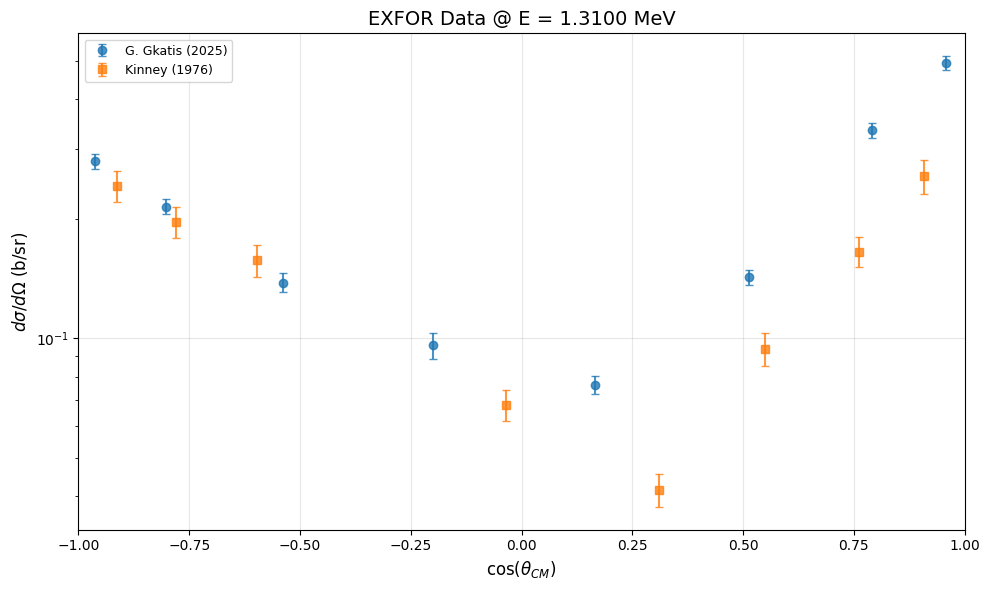

In [55]:
if exfor_df.empty:
    print("No data to plot")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Color palette for experiments
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    
    # Plot each experiment with different color
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            # Find experiment info
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.8
        )
    
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
    ax.set_title(f'EXFOR Data @ E = {bin_info.energy_mev:.4f} MeV', fontsize=14)
    ax.set_xlim(-1, 1)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

## 8. Perform Nominal Fit

Fit Legendre coefficients to the EXFOR data using the nominal (best-fit) approach.

In [56]:
if exfor_df.empty:
    print("No data available for fitting")
    nominal_coeffs = None
    fit_info = None
else:
    print("Performing nominal Legendre fit...")
    
    # Perform nominal fit (n_samples=1)
    coef_df, fit_info = sample_legendre_coefficients(
        exfor_df,
        value_col="value",
        unc_col="unc",
        degree=None,  # Auto-select using AICc/BIC
        max_degree=MAX_LEGENDRE_DEGREE,
        select_degree=SELECT_DEGREE,
        ridge_lambda=RIDGE_LAMBDA,
        external_weights=kernel_weights,
        n_samples=1,
        use_band_discrepancy=USE_BAND_DISCREPANCY,
        min_points_per_band=MIN_POINTS_PER_BAND,
        max_tau_fraction=MAX_TAU_FRACTION,
    )
    
    # Extract nominal coefficients
    nominal_coeffs = coef_df.iloc[0].to_numpy()
    fitted_degree = fit_info['degree']
    chi2_red = fit_info['chi2_red']
    tau_info = fit_info.get('tau_info', {})
    
    print(f"\nFit Results:")
    print(f"  Selected degree: L = {fitted_degree}")
    print(f"  Reduced chi-squared: {chi2_red:.3f}")
    print(f"  Effective parameters: {fit_info.get('eff_params', fitted_degree + 1)}")
    
    if tau_info:
        print(f"\nBand discrepancy (tau values):")
        print(f"  tau_F (forward, mu > 0.5):  {tau_info.get('tau_F', 0):.4f}")
        print(f"  tau_M (mid, |mu| <= 0.5):   {tau_info.get('tau_M', 0):.4f}")
        print(f"  tau_B (backward, mu < -0.5): {tau_info.get('tau_B', 0):.4f}")
    
    print(f"\nFitted Legendre coefficients [c0, c1, ..., c{fitted_degree}]:")
    for i, c in enumerate(nominal_coeffs):
        print(f"  c{i} = {c:+.6f}")

Performing nominal Legendre fit...

Fit Results:
  Selected degree: L = 4
  Reduced chi-squared: 16.819
  Effective parameters: 4.999999981812689

Band discrepancy (tau values):
  tau_F (forward, mu > 0.5):  0.0527
  tau_M (mid, |mu| <= 0.5):   0.0169
  tau_B (backward, mu < -0.5): 0.0000

Fitted Legendre coefficients [c0, c1, ..., c4]:
  c0 = +0.156814
  c1 = +0.032203
  c2 = +0.205924
  c3 = +0.077551
  c4 = +0.043185


## 9. Visualize Nominal Fit vs Data

Compare the nominal fit curve with the experimental data.

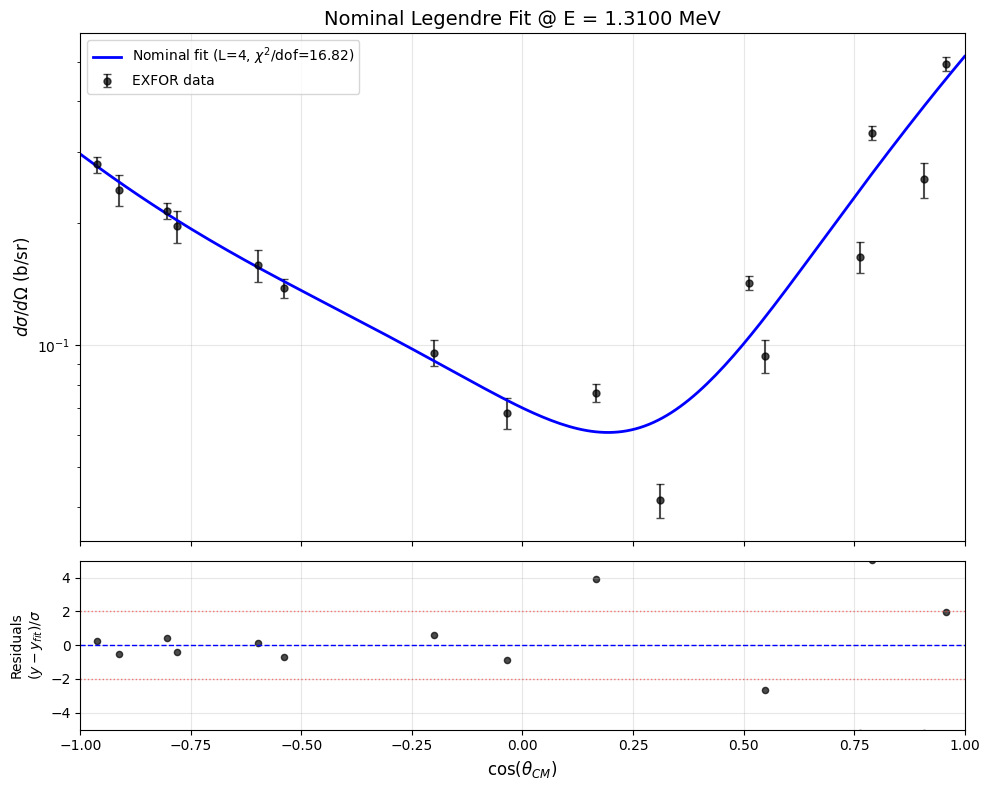


Residual statistics:
  Mean: -0.187 (should be ~0)
  Std: 3.395 (should be ~1 if chi2/dof ~1)
  Points outside +/-2 sigma: 7/16


In [57]:
if nominal_coeffs is None:
    print("No fit available")
else:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[3, 1], sharex=True)
    
    # Grid for fit curve
    mu_grid = np.linspace(-1, 1, 200)
    y_fit = legval(mu_grid, nominal_coeffs)
    
    # Plot data
    ax1.errorbar(
        exfor_df['mu'], exfor_df['value'], yerr=exfor_df['unc'],
        fmt='o', color='black', label='EXFOR data',
        capsize=3, markersize=5, alpha=0.7
    )
    
    # Plot nominal fit
    ax1.plot(mu_grid, y_fit, 'b-', linewidth=2, 
             label=f'Nominal fit (L={fit_info["degree"]}, $\\chi^2$/dof={chi2_red:.2f})')
    
    ax1.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
    ax1.set_title(f'Nominal Legendre Fit @ E = {bin_info.energy_mev:.4f} MeV', fontsize=14)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Residuals plot
    mu_data = exfor_df['mu'].values
    y_data = exfor_df['value'].values
    sigma_data = exfor_df['unc'].values
    y_fit_at_data = legval(mu_data, nominal_coeffs)
    residuals = (y_data - y_fit_at_data) / sigma_data
    
    ax2.scatter(mu_data, residuals, c='black', s=20, alpha=0.7)
    ax2.axhline(0, color='blue', linestyle='--', linewidth=1)
    ax2.axhline(2, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.axhline(-2, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
    ax2.set_ylabel('Residuals\n$(y - y_{fit})/\\sigma$', fontsize=10)
    ax2.set_xlim(-1, 1)
    ax2.set_ylim(-5, 5)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Residual statistics
    print(f"\nResidual statistics:")
    print(f"  Mean: {np.mean(residuals):.3f} (should be ~0)")
    print(f"  Std: {np.std(residuals):.3f} (should be ~1 if chi2/dof ~1)")
    print(f"  Points outside +/-2 sigma: {np.sum(np.abs(residuals) > 2)}/{len(residuals)}")

## 10. Generate MC Samples

Generate Monte Carlo samples of Legendre coefficients by jittering the data.

In [58]:
if exfor_df.empty:
    print("No data available for sampling")
    all_samples = None
else:
    print(f"Generating {N_SAMPLES} MC samples...")
    np.random.seed(BASE_SEED)
    
    # Generate samples
    samples_df, samples_info = sample_legendre_coefficients(
        exfor_df,
        value_col="value",
        unc_col="unc",
        degree=fit_info['degree'],  # Use frozen degree from nominal fit
        max_degree=MAX_LEGENDRE_DEGREE,
        ridge_lambda=RIDGE_LAMBDA,
        external_weights=kernel_weights,
        n_samples=N_SAMPLES,
        use_band_discrepancy=USE_BAND_DISCREPANCY,
        min_points_per_band=MIN_POINTS_PER_BAND,
        max_tau_fraction=MAX_TAU_FRACTION,
    )
    
    # Convert to numpy array
    all_samples = samples_df.to_numpy()  # Shape: (N_SAMPLES, n_coeffs)
    
    # Compute MC statistics
    mc_mean = np.mean(all_samples, axis=0)
    mc_std = np.std(all_samples, axis=0)
    
    print(f"\nMC Sample Statistics (L={fit_info['degree']}):")
    print(f"{'Coeff':<6} {'Nominal':>12} {'MC Mean':>12} {'MC Std':>12} {'Unc %':>10}")
    print("-" * 56)
    for i in range(len(mc_mean)):
        unc_pct = 100 * mc_std[i] / abs(mc_mean[i]) if mc_mean[i] != 0 else 0.0
        print(f"c{i:<5} {nominal_coeffs[i]:>+12.6f} {mc_mean[i]:>+12.6f} {mc_std[i]:>12.6f} {unc_pct:>9.1f}%")

Generating 25 MC samples...

MC Sample Statistics (L=4):
Coeff       Nominal      MC Mean       MC Std      Unc %
--------------------------------------------------------
c0        +0.156814    +0.154275     0.005944       3.9%
c1        +0.032203    +0.026907     0.013963      51.9%
c2        +0.205924    +0.203609     0.015556       7.6%
c3        +0.077551    +0.077082     0.020605      26.7%
c4        +0.043185    +0.051683     0.018518      35.8%


## 11. Compare with Original ENDF

Convert fitted coefficients to ENDF format and compare with the original evaluation.

In [59]:
if nominal_coeffs is None:
    print("No fit available")
else:
    # Convert fitted coefficients to ENDF format
    # ENDF: a_l = (c_l / c_0) / (2l+1) for l>=1, a_0 = 1
    fitted_endf_coeffs = endf_normalize_legendre_coeffs(nominal_coeffs, include_a0=True)
    mc_mean_endf_coeffs = endf_normalize_legendre_coeffs(mc_mean, include_a0=True)
    
    print(f"Coefficient Comparison (ENDF format, a_l):")
    print(f"{'Order':<6} {'Original ENDF':>14} {'Nominal Fit':>14} {'MC Mean':>14}")
    print("-" * 52)
    
    # a0 is always 1 by convention
    print(f"{'a0':<6} {'1.000000':>14} {'1.000000':>14} {'1.000000':>14}")
    
    # Compare higher orders
    max_order = max(len(original_endf_coeffs), len(fitted_endf_coeffs) - 1)
    for l in range(1, max_order + 1):
        orig_val = original_endf_coeffs[l-1] if l <= len(original_endf_coeffs) else 0.0
        fit_val = fitted_endf_coeffs[l] if l < len(fitted_endf_coeffs) else 0.0
        mc_val = mc_mean_endf_coeffs[l] if l < len(mc_mean_endf_coeffs) else 0.0
        print(f"a{l:<5} {orig_val:>+14.6f} {fit_val:>+14.6f} {mc_val:>+14.6f}")

Coefficient Comparison (ENDF format, a_l):
Order   Original ENDF    Nominal Fit        MC Mean
----------------------------------------------------
a0           1.000000       1.000000       1.000000
a1          -0.099923      +0.068453      +0.058136
a2          +0.224521      +0.262635      +0.263956
a3          +0.057129      +0.070649      +0.071377
a4          +0.015897      +0.030599      +0.037223
a5          -0.013064      +0.000000      +0.000000
a6          +0.004601      +0.000000      +0.000000


## 12. Main Visualization: All Fits and Samples

**This is the key output figure** showing:
- Original ENDF evaluation (dashed black line)
- Nominal fit (solid blue line)
- MC mean fit (solid red line)
- MC samples (thin gray lines, low opacity)
- EXFOR data points with error bars

In [60]:
def endf_angular_dist(mu, a_coeffs):
    """
    Compute angular distribution from ENDF-format coefficients.
    
    ENDF format: f(mu) = (1/2) * sum_{l=0}^{L} (2l+1) * a_l * P_l(mu)
    where a_0 = 1 (implicit) and a_coeffs = [a1, a2, ...]
    
    Parameters:
        mu: cosine values (array)
        a_coeffs: ENDF coefficients [a1, a2, ..., aL] (a0=1 implicit)
    
    Returns:
        Angular distribution values (normalized PDF, not cross section)
    """
    from scipy.special import legendre
    mu = np.atleast_1d(mu)
    
    # Start with a0 = 1
    result = 0.5 * 1.0 * np.ones_like(mu)  # (2*0+1)/2 * a0 * P0 = 0.5 * 1 * 1
    
    # Add higher orders
    for l, a_l in enumerate(a_coeffs, start=1):
        P_l = legendre(l)(mu)
        result += 0.5 * (2*l + 1) * a_l * P_l
    
    return result


def compute_energy_folded_cross_section(
    ace_data,
    target_energy_mev,
    mt_number,
    sigma_E_mev,
    n_sigma=4.0
):
    """
    Compute energy-folded total cross section using ACE data.
    
    This is the CORRECT approach for energy folding:
    - Folding is applied to the total cross section, NOT to Legendre coefficients
    - Uses Gaussian weighting based on TOF energy resolution
    
    Parameters:
        ace_data: ACE data object from kika.read_ace()
        target_energy_mev: Central energy for folding (MeV)
        mt_number: Reaction MT number (e.g., 2 for elastic)
        sigma_E_mev: Energy resolution sigma (MeV)
        n_sigma: Number of sigma for integration window (default 4.0)
    
    Returns:
        tuple: (folded_xs, original_xs) - both in barns
    """
    # Get cross section data from ACE
    xs_data = ace_data.cross_section.to_plot_data(mt=mt_number)
    energies_mev = xs_data.x  # Energy grid in MeV
    xs_values = xs_data.y     # Cross section values in barns
    
    # Find energy window for folding
    E_min = max(target_energy_mev - n_sigma * sigma_E_mev, energies_mev.min())
    E_max = min(target_energy_mev + n_sigma * sigma_E_mev, energies_mev.max())
    
    # Select energies in window
    mask = (energies_mev >= E_min) & (energies_mev <= E_max)
    E_window = energies_mev[mask]
    xs_window = xs_values[mask]
    
    if len(E_window) == 0:
        # Fallback: use closest energy
        idx = np.argmin(np.abs(energies_mev - target_energy_mev))
        return xs_values[idx], xs_values[idx]
    
    # Compute Gaussian weights
    weights = np.exp(-0.5 * ((E_window - target_energy_mev) / sigma_E_mev) ** 2)
    
    # Compute energy bin widths for integration
    dE = np.diff(E_window)
    dE_full = np.zeros_like(E_window)
    if len(dE) > 0:
        dE_full[0] = dE[0]
        dE_full[-1] = dE[-1]
        if len(dE) > 1:
            dE_full[1:-1] = (dE[:-1] + dE[1:]) / 2
    else:
        dE_full[0] = 1.0  # Single point
    
    # Folded cross section: weighted average
    weighted_sum = np.sum(weights * xs_window * dE_full)
    norm = np.sum(weights * dE_full)
    folded_xs = weighted_sum / norm if norm > 0 else xs_window[len(xs_window)//2]
    
    # Original (unfolded) cross section at target energy
    idx_orig = np.argmin(np.abs(energies_mev - target_energy_mev))
    original_xs = xs_values[idx_orig]
    
    return folded_xs, original_xs


# Test: the integral of f(mu) from -1 to 1 should be 1
mu_test = np.linspace(-1, 1, 1000)
f_test = endf_angular_dist(mu_test, original_endf_coeffs)
integral = np.trapezoid(f_test, mu_test)
print(f"Test: integral of ENDF angular dist = {integral:.6f} (should be ~1.0)")

# Load ACE data for cross section folding
print(f"\nLoading ACE data for cross section folding...")
try:
    import kika
    ace_data = kika.read_ace(ACE_FILE_PATH)
    
    # Compute folded cross section
    folded_xs, original_xs = compute_energy_folded_cross_section(
        ace_data=ace_data,
        target_energy_mev=bin_info.energy_mev,
        mt_number=MT_NUMBER,
        sigma_E_mev=bin_info.sigma_E_mev,
        n_sigma=4.0
    )
    
    print(f"ACE data loaded successfully")
    print(f"Energy resolution for folding: sigma_E = {bin_info.sigma_E_mev*1000:.2f} keV")
    print(f"Original cross section at {bin_info.energy_mev:.4f} MeV: {original_xs:.4f} b")
    print(f"Energy-folded cross section: {folded_xs:.4f} b")
    print(f"Folding factor (folded/original): {folded_xs/original_xs:.4f}")
    
    ACE_LOADED = True
except Exception as e:
    print(f"WARNING: Could not load ACE data: {e}")
    print("Proceeding without cross section folding")
    ACE_LOADED = False
    folded_xs = 1.0
    original_xs = 1.0

Test: integral of ENDF angular dist = 1.000002 (should be ~1.0)

Loading ACE data for cross section folding...
ACE data loaded successfully
Energy resolution for folding: sigma_E = 7.67 keV
Original cross section at 1.3100 MeV: 1.0190 b
Energy-folded cross section: 1.9263 b
Folding factor (folded/original): 1.8904


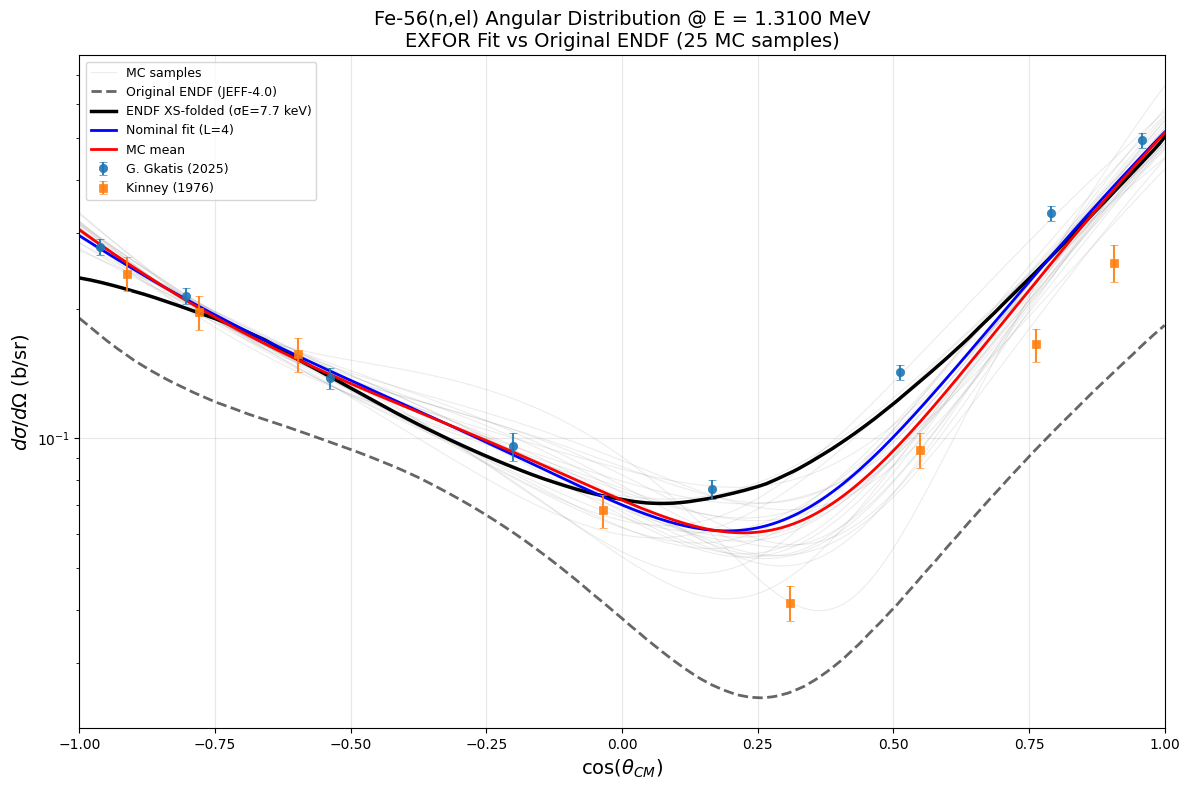

In [61]:
if nominal_coeffs is None:
    print("No fit available")
else:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Grid for curves
    mu_grid = np.linspace(-1, 1, 200)
    
    # Color palette and markers for experiments
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    
    # 1. Plot MC samples (first, so they're in background)
    if all_samples is not None:
        for i in range(min(N_SAMPLES, 25)):
            y_sample = legval(mu_grid, all_samples[i])
            label = 'MC samples' if i == 0 else None
            ax.plot(mu_grid, y_sample, '-', color='gray', alpha=0.15, linewidth=0.8, label=label)
    
    # 2. Original ACE evaluation (unfolded) - using same implementation as demo_ace_vs_exfor_angular.ipynb
    if ACE_LOADED:
        ace_unfolded = ace_data.angular_distributions.to_plot_data(
            mt=MT_NUMBER,
            energy=bin_info.energy_mev,
            ace=ace_data,
            interpolate=True,
            num_points=200,
            normalize_to_xs=True,
            cross_section_unit='b/sr',
        )
        ax.plot(ace_unfolded.x, ace_unfolded.y, 'k--', linewidth=2, alpha=0.6, 
                label='Original ENDF (JEFF-4.0)')
    
    # 3. Energy-folded ACE evaluation - using same implementation as demo_ace_vs_exfor_angular.ipynb
    if ACE_LOADED:
        ace_folded = ace_data.angular_distributions.to_plot_data(
            mt=MT_NUMBER,
            energy=bin_info.energy_mev,
            ace=ace_data,
            interpolate=True,
            num_points=200,
            normalize_to_xs=True,
            cross_section_unit='b/sr',
            energy_folding=True,
            tof=(FLIGHT_PATH_M, DELTA_T_NS),
        )
        ax.plot(ace_folded.x, ace_folded.y, 'k-', linewidth=2.5, 
                label=f'ENDF XS-folded (σE={bin_info.sigma_E_mev*1000:.1f} keV)')
    
    # 4. Nominal fit
    y_nominal = legval(mu_grid, nominal_coeffs)
    ax.plot(mu_grid, y_nominal, 'b-', linewidth=2, 
            label=f'Nominal fit (L={fit_info["degree"]})')
    
    # 5. MC mean fit
    if all_samples is not None:
        y_mc_mean = legval(mu_grid, mc_mean)
        ax.plot(mu_grid, y_mc_mean, 'r-', linewidth=2, label='MC mean')
    
    # 6. EXFOR data points - different color per experiment
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.9,
            markeredgewidth=0.5
        )
    
    # Formatting
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
    ax.set_title(
        f'Fe-56(n,el) Angular Distribution @ E = {bin_info.energy_mev:.4f} MeV\n'
        f'EXFOR Fit vs Original ENDF ({N_SAMPLES} MC samples)',
        fontsize=14
    )
    ax.set_xlim(-1, 1)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

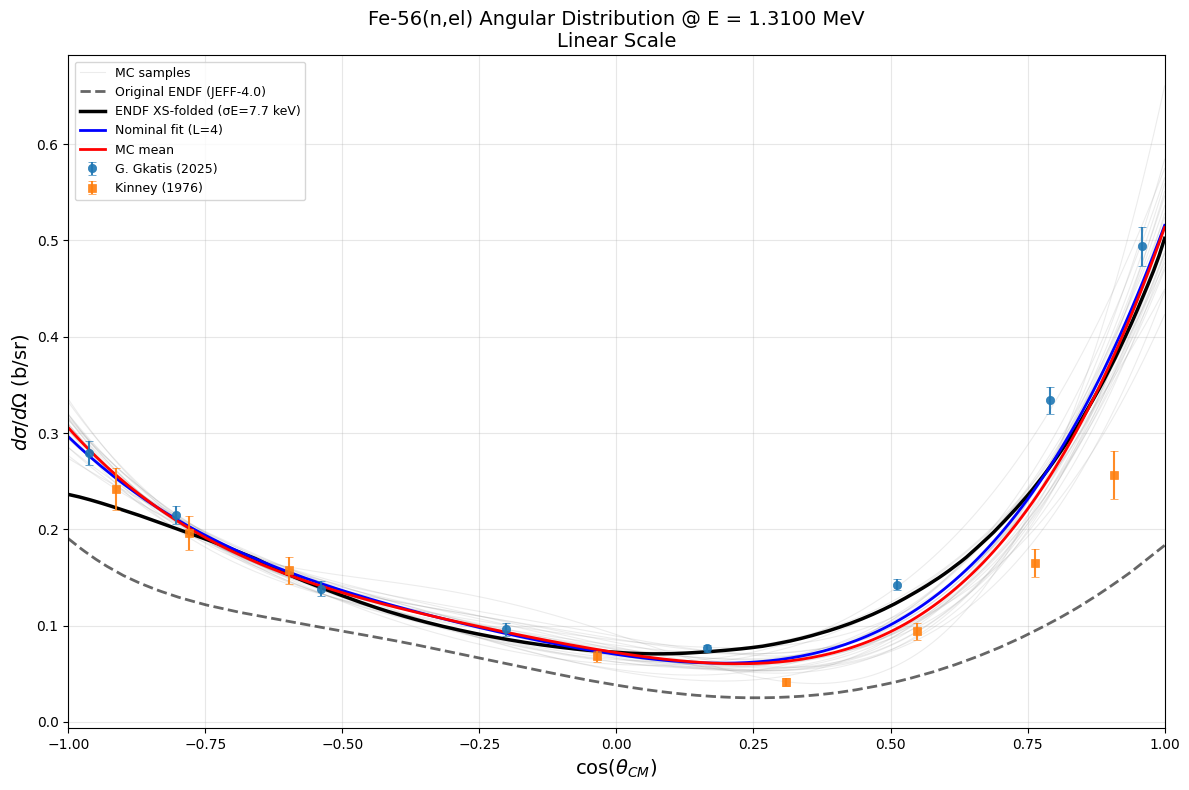

In [62]:
# Same plot with LINEAR scale
if nominal_coeffs is not None:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    mu_grid = np.linspace(-1, 1, 200)
    
    # Color palette and markers for experiments
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    
    # MC samples
    if all_samples is not None:
        for i in range(min(N_SAMPLES, 25)):
            y_sample = legval(mu_grid, all_samples[i])
            label = 'MC samples' if i == 0 else None
            ax.plot(mu_grid, y_sample, '-', color='gray', alpha=0.15, linewidth=0.8, label=label)
    
    # Original ACE evaluation (unfolded) - using same implementation as demo_ace_vs_exfor_angular.ipynb
    if ACE_LOADED:
        ace_unfolded = ace_data.angular_distributions.to_plot_data(
            mt=MT_NUMBER,
            energy=bin_info.energy_mev,
            ace=ace_data,
            interpolate=True,
            num_points=200,
            normalize_to_xs=True,
            cross_section_unit='b/sr',
        )
        ax.plot(ace_unfolded.x, ace_unfolded.y, 'k--', linewidth=2, alpha=0.6, 
                label='Original ENDF (JEFF-4.0)')
    
    # Energy-folded ACE evaluation - using same implementation as demo_ace_vs_exfor_angular.ipynb
    if ACE_LOADED:
        ace_folded = ace_data.angular_distributions.to_plot_data(
            mt=MT_NUMBER,
            energy=bin_info.energy_mev,
            ace=ace_data,
            interpolate=True,
            num_points=200,
            normalize_to_xs=True,
            cross_section_unit='b/sr',
            energy_folding=True,
            tof=(FLIGHT_PATH_M, DELTA_T_NS),
        )
        ax.plot(ace_folded.x, ace_folded.y, 'k-', linewidth=2.5, 
                label=f'ENDF XS-folded (σE={bin_info.sigma_E_mev*1000:.1f} keV)')
    
    # Nominal fit
    y_nominal = legval(mu_grid, nominal_coeffs)
    ax.plot(mu_grid, y_nominal, 'b-', linewidth=2, 
            label=f'Nominal fit (L={fit_info["degree"]})')
    
    # MC mean
    if all_samples is not None:
        y_mc_mean = legval(mu_grid, mc_mean)
        ax.plot(mu_grid, y_mc_mean, 'r-', linewidth=2, label='MC mean')
    
    # EXFOR data - different color per experiment
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.9,
            markeredgewidth=0.5
        )
    
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
    ax.set_title(
        f'Fe-56(n,el) Angular Distribution @ E = {bin_info.energy_mev:.4f} MeV\n'
        f'Linear Scale',
        fontsize=14
    )
    ax.set_xlim(-1, 1)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 13. Coefficient Comparison Plot

Visualize the differences in Legendre coefficients between methods.

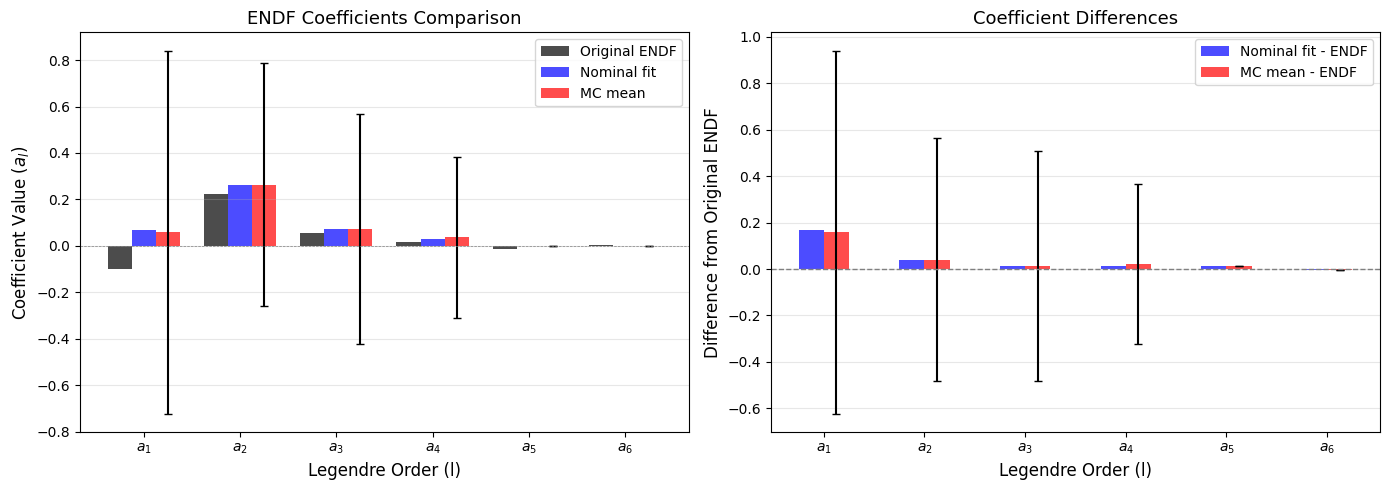

In [63]:
if nominal_coeffs is None:
    print("No fit available")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Convert to ENDF format for comparison
    fitted_a = endf_normalize_legendre_coeffs(nominal_coeffs, include_a0=True)
    mc_mean_a = endf_normalize_legendre_coeffs(mc_mean, include_a0=True)
    mc_std_a = endf_normalize_legendre_coeffs(mc_std, include_a0=True)  # Approximate
    
    # Prepare data for plotting
    max_order = max(len(original_endf_coeffs), len(fitted_a) - 1)
    orders = np.arange(1, max_order + 1)
    
    orig_vals = np.array([original_endf_coeffs[l-1] if l <= len(original_endf_coeffs) else 0.0 
                         for l in orders])
    fit_vals = np.array([fitted_a[l] if l < len(fitted_a) else 0.0 for l in orders])
    mc_vals = np.array([mc_mean_a[l] if l < len(mc_mean_a) else 0.0 for l in orders])
    mc_errs = np.array([abs(mc_std_a[l]) if l < len(mc_std_a) else 0.0 for l in orders])
    
    # Left plot: Coefficient values
    width = 0.25
    x = np.arange(len(orders))
    
    ax1.bar(x - width, orig_vals, width, label='Original ENDF', color='black', alpha=0.7)
    ax1.bar(x, fit_vals, width, label='Nominal fit', color='blue', alpha=0.7)
    ax1.bar(x + width, mc_vals, width, label='MC mean', color='red', alpha=0.7, 
           yerr=mc_errs, capsize=3)
    
    ax1.set_xlabel('Legendre Order (l)', fontsize=12)
    ax1.set_ylabel('Coefficient Value ($a_l$)', fontsize=12)
    ax1.set_title('ENDF Coefficients Comparison', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'$a_{l}$' for l in orders])
    ax1.legend(fontsize=10)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Right plot: Differences from original ENDF
    diff_fit = fit_vals - orig_vals
    diff_mc = mc_vals - orig_vals
    
    ax2.bar(x - width/2, diff_fit, width, label='Nominal fit - ENDF', color='blue', alpha=0.7)
    ax2.bar(x + width/2, diff_mc, width, label='MC mean - ENDF', color='red', alpha=0.7,
           yerr=mc_errs, capsize=3)
    
    ax2.set_xlabel('Legendre Order (l)', fontsize=12)
    ax2.set_ylabel('Difference from Original ENDF', fontsize=12)
    ax2.set_title('Coefficient Differences', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'$a_{l}$' for l in orders])
    ax2.legend(fontsize=10)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 14. Summary Statistics

In [64]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nEnergy: {bin_info.energy_mev:.6f} MeV")
print(f"Energy bin: [{bin_info.bin_lower_mev:.6f}, {bin_info.bin_upper_mev:.6f}] MeV")
print(f"Method: {EXPERIMENT_SELECTION_METHOD}")

print(f"\nData:")
print(f"  Experiments: {len(experiments_info)}")
print(f"  Total points: {len(exfor_df)}")
if diagnostics:
    print(f"  N_eff: {diagnostics.n_eff:.1f}")

if fit_info:
    print(f"\nFit:")
    print(f"  Legendre degree: {fit_info['degree']}")
    print(f"  chi2/dof: {fit_info['chi2_red']:.3f}")
    tau = fit_info.get('tau_info', {})
    if tau:
        print(f"  tau_F: {tau.get('tau_F', 0):.4f}")
        print(f"  tau_M: {tau.get('tau_M', 0):.4f}")
        print(f"  tau_B: {tau.get('tau_B', 0):.4f}")

if all_samples is not None:
    print(f"\nMC Sampling:")
    print(f"  N_samples: {N_SAMPLES}")
    print(f"  Coefficient spread (c0): {mc_std[0]:.6f}")

print("\n" + "=" * 60)

SUMMARY

Energy: 1.310000 MeV
Energy bin: [1.309500, 1.310500] MeV
Method: energy_bin

Data:
  Experiments: 2
  Total points: 16
  N_eff: 16.0

Fit:
  Legendre degree: 4
  chi2/dof: 16.819
  tau_F: 0.0527
  tau_M: 0.0169
  tau_B: 0.0000

MC Sampling:
  N_samples: 25
  Coefficient spread (c0): 0.005944



## Next Steps

1. **Change TARGET_ENERGY_MEV** at the top to explore different energies
2. **Try different methods**: Change `EXPERIMENT_SELECTION_METHOD` to `"kernel_weights"`
3. **Adjust fitting parameters**: Modify `MAX_LEGENDRE_DEGREE`, `SELECT_DEGREE`, etc.
4. **Increase samples**: Change `N_SAMPLES` for better uncertainty estimates